# Demo: Effective Potential with RGE

This notebook demonstrates how to evaluate and visualize the one-loop thermal effective potential $V_{\rm eff}(\phi, T; \mu)$ using `VeffFunc_RGE`.

**Pipeline step:** The effective potential is the second layer — it wraps RGE running and provides the scalar potential to the bounce solvers.

**Module used:** `src/RGE/VeffFunc_RGE.py`

**Structure of $V_{\rm eff}$:**
$$V_{\rm eff}(\phi, T; \mu) = V_{\rm tree}(\phi; \mu) + V_{\rm CW}(\phi; \mu) + V_T(\phi, T) + V_{\rm daisy}(\phi, T)$$
where all couplings are evaluated at scale $\mu$ via the RGE.

**Contents:**
1. Scale variation of the potential at low temperature
2. Thermal corrections: how the potential changes with $T$
3. Saving potential curve data

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [22]:
# Instantiate the effective potential with the thermal J_B table
V = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")

# Model parameters (matching cs.gD0, cs.lambdaS0 defaults)
gD0 = 0.6
ls0 = 1e-10

# Field range for plotting
S = np.linspace(0.0, 5, 10000)

## 1. Scale variation at low temperature

At $T \ll v$, the thermal corrections are negligible and the potential is dominated by the tree + Coleman–Weinberg terms. We use the high-$T$ expanded form `Veff_HighT` here for speed, which coincides with the full potential at low $T$.

The three curves show $\mu = \pi/4,\, \pi,\, 4\pi$ — the spread quantifies the residual renormalization-scale dependence.

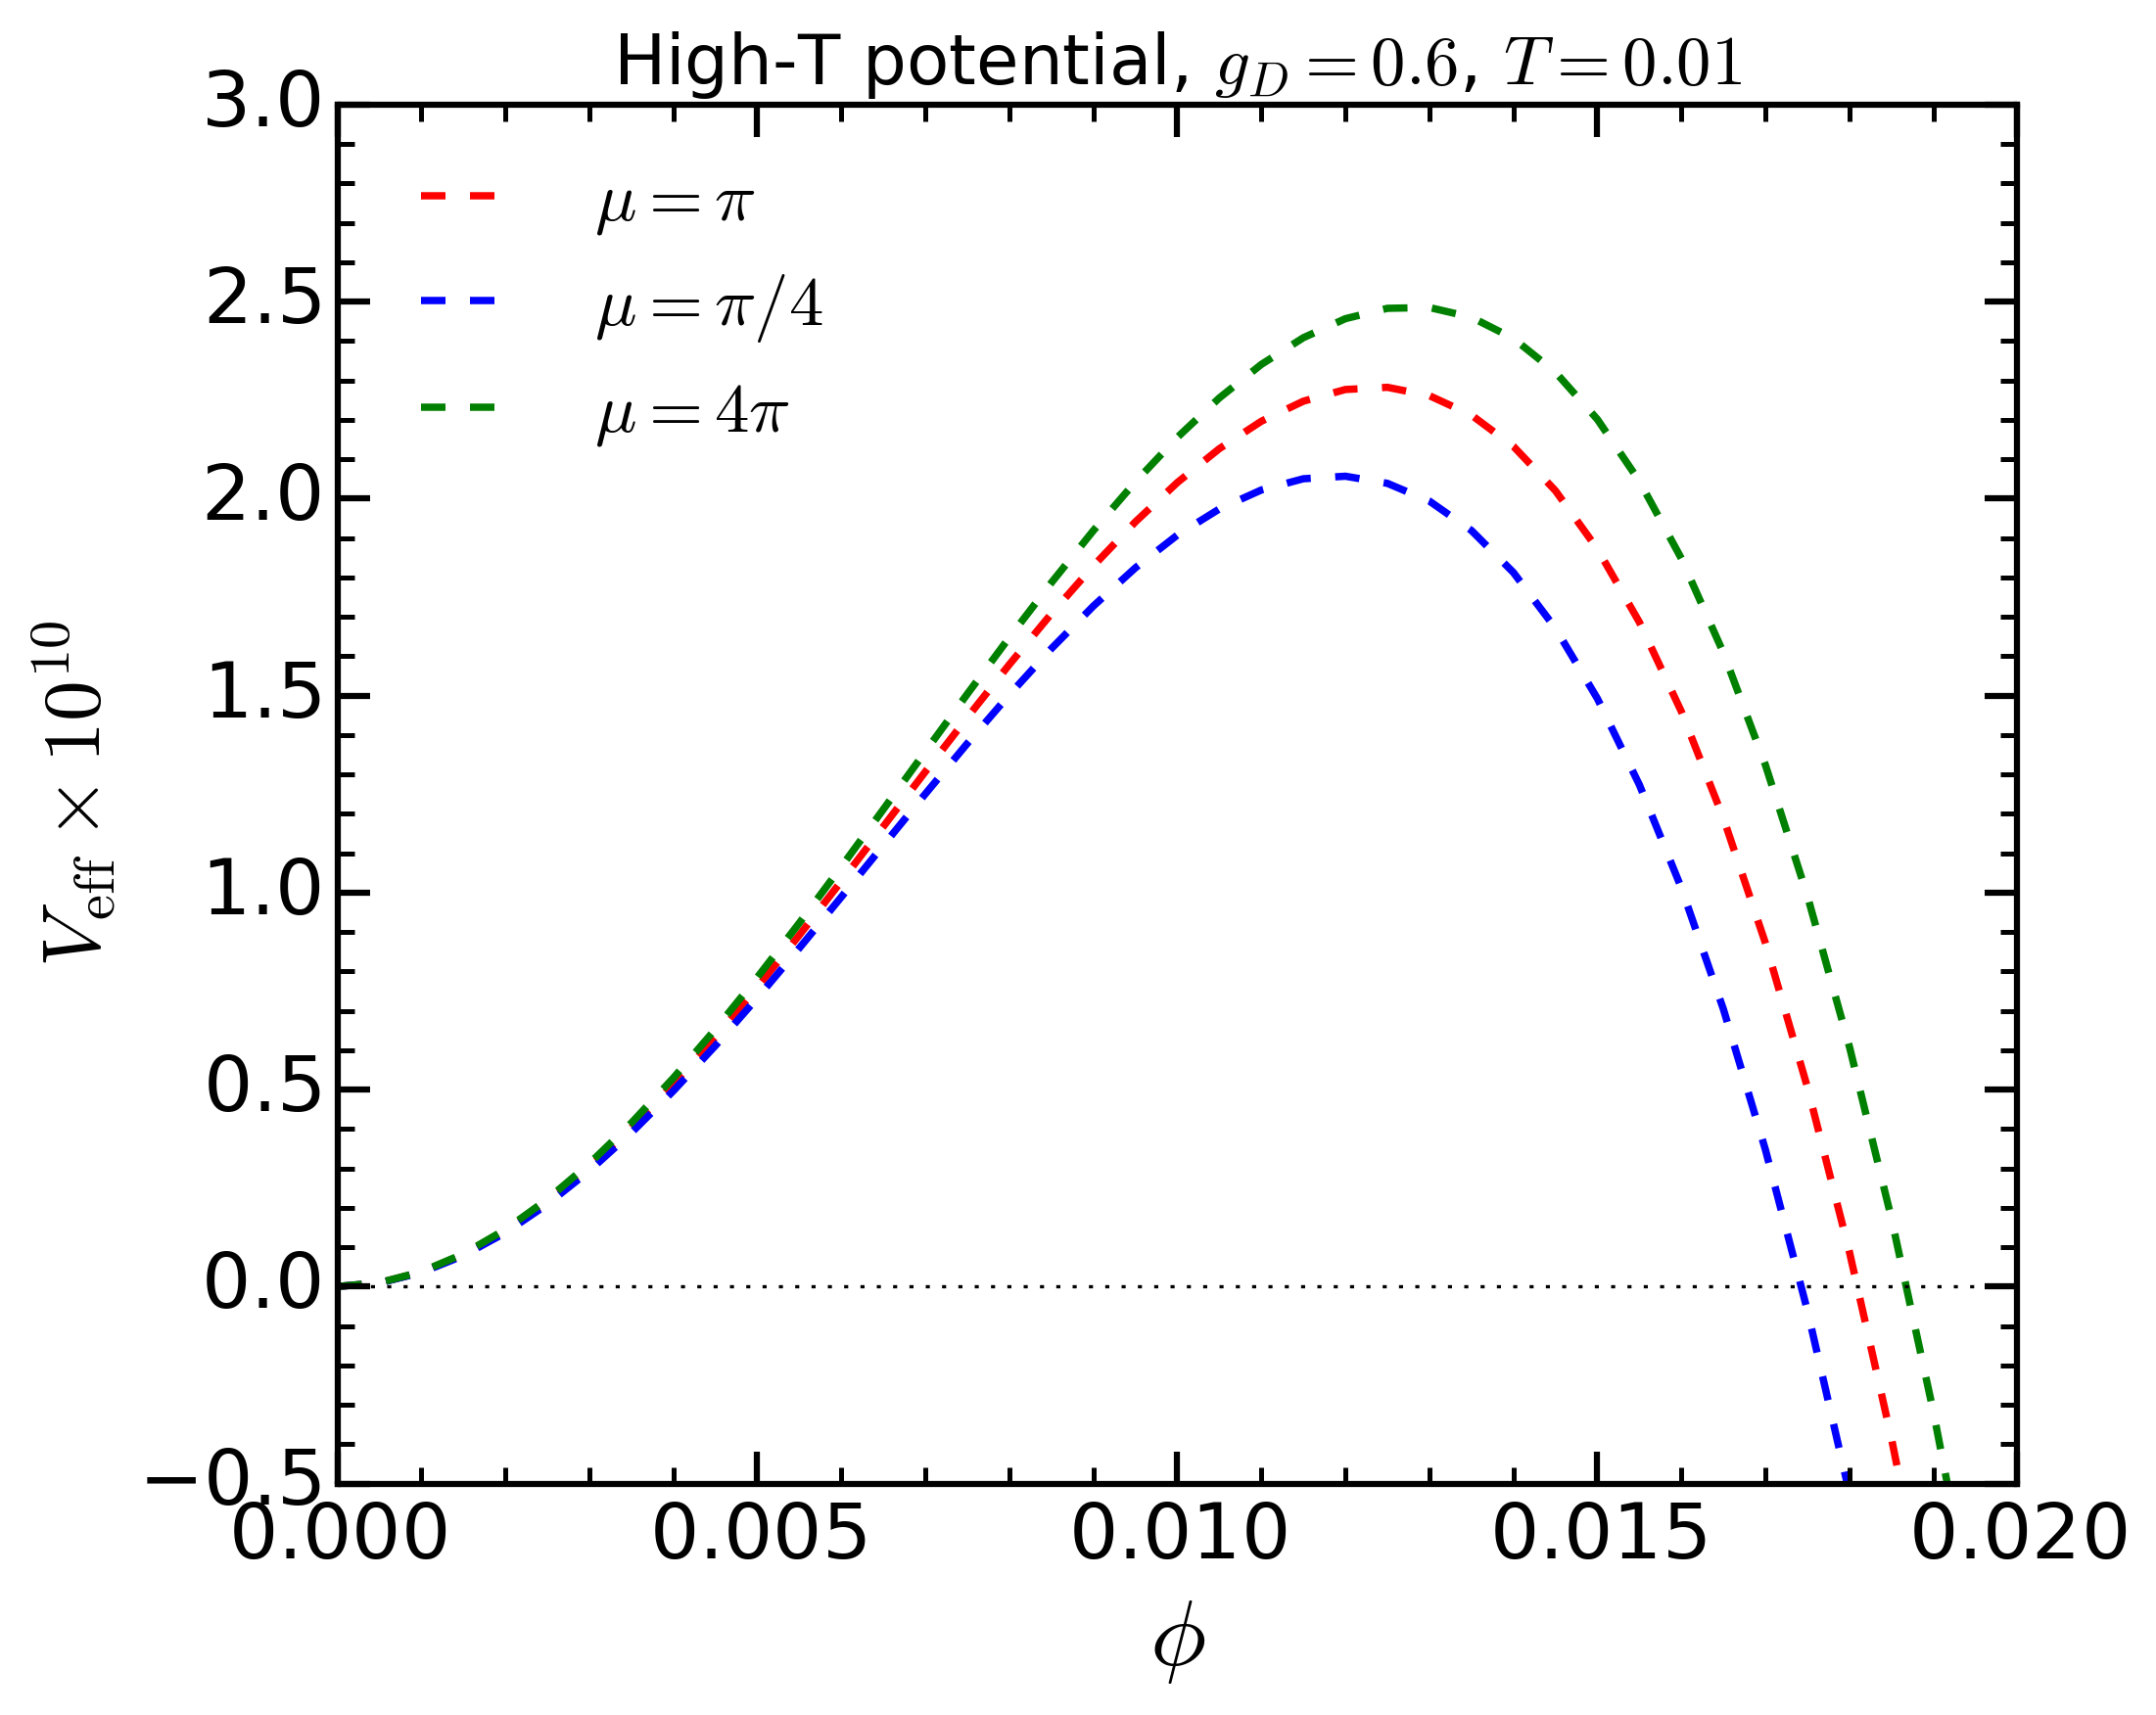

In [23]:
T_low = 0.01   # temperature much below the VEV

# Evaluate the high-T expanded potential at three renormalization scales
# (factor 1e10 rescales to visible units for gD=0.6, ls0~0)
y_pi      = V.Veff_HighT(S, T_low, gD0, np.pi,     ls0) * 1e10
y_pi_ov4  = V.Veff_HighT(S, T_low, gD0, np.pi/4,   ls0) * 1e10
y_pi_by4  = V.Veff_HighT(S, T_low, gD0, np.pi*4,   ls0) * 1e10

fig, ax = new_figure(figsize=(7.5, 6), dpi=300)
fig.patch.set_facecolor('white')

ax.plot(S, y_pi,     color='red',   ls='--', lw=1.8, label=r'$\mu = \pi$')
ax.plot(S, y_pi_ov4, color='blue',  ls='--', lw=1.8, label=r'$\mu = \pi/4$')
ax.plot(S, y_pi_by4, color='green', ls='--', lw=1.8, label=r'$\mu = 4\pi$')
ax.axhline(0, color='k', lw=0.8, ls=':')

ps.apply_standard_formatting(
    ax,
    ylog=False,
    xlabel=r'$\phi$',
    ylabel=r'$V_{\rm eff}\times 10^{10}$',
    title=fr'High-T potential, $g_D={gD0}$, $T={T_low}$',
    xlim=(0.0, 0.02),
    ylim=(-0.5, 3),
)
ax.legend(frameon = False, loc='best', ncol=1, fontsize=17)
plt.tight_layout()

In [ ]:
# Save the three curves for downstream use
np.savetxt(
    "../data/raw_data/V_full_curve_gD06_mu_piover4_to_pi4.dat",
    np.column_stack([S, y_pi, y_pi_ov4, y_pi_by4]),
    header="phi   V_ht_pi   V_ht_pi_over4   V_ht_pi_by4",
    fmt="%.10e"
)
print("Saved: data/raw_data/V_full_curve_gD06_mu_piover4_to_pi4.dat")

## 2. Thermal corrections

As $T$ increases toward the critical temperature $T_c$, the thermal mass lifts the broken minimum and eventually restores the $\phi\to 0$ symmetry. We compare the full potential `Veff` and the high-$T$ expansion `Veff_HighT` at several temperatures to show where the approximation breaks down.

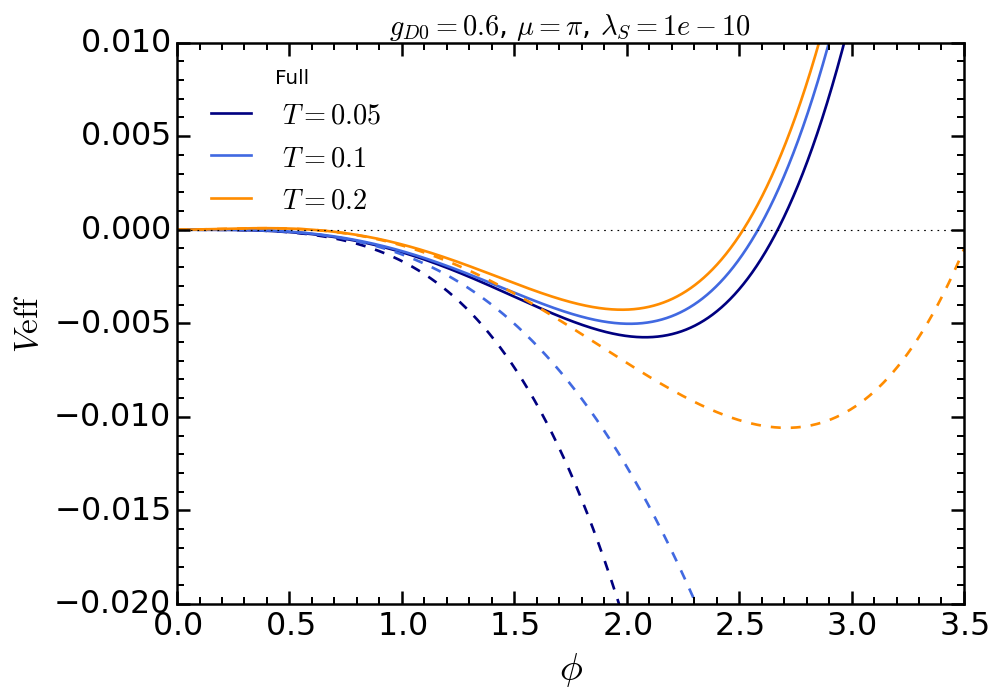

In [60]:
scale    = np.pi    # renormalization scale
T_vals   = [ 0.05, 0.1, 0.2]
colors_T = ['navy', 'royalblue', 'darkorange', 'crimson']

fig, ax = new_figure(figsize=(8.5, 6), dpi=120)
fig.patch.set_facecolor('white')

for T, c in zip(T_vals, colors_T):
    y_full = V.Veff(S, T, gD0, scale, ls0)
    y_ht   = V.Veff_HighT(S, T, gD0, scale, ls0)

    ax.plot(S, y_full , color=c, lw=1.6, ls='-',  label=fr'$T={T}$')
    ax.plot(S, y_ht  , color=c, lw=1.6, ls='--')

ax.axhline(0, color='k', lw=0.7, ls=':')
ps.apply_standard_formatting(
    ax,
    ylog=False,
    xlabel=r'$\phi$',
    ylabel=r'$V{\rm eff}$',
    title=fr'$g_{{D0}}={gD0}$, $\mu=\pi$, $\lambda_S={ls0}$ ',
    xlim=(0, 3.5),
    ylim=(-0.02,0.01)
)
ax.legend(loc='best', frameon=False, fontsize=17, ncol = 1, title = 'Full')
plt.tight_layout()